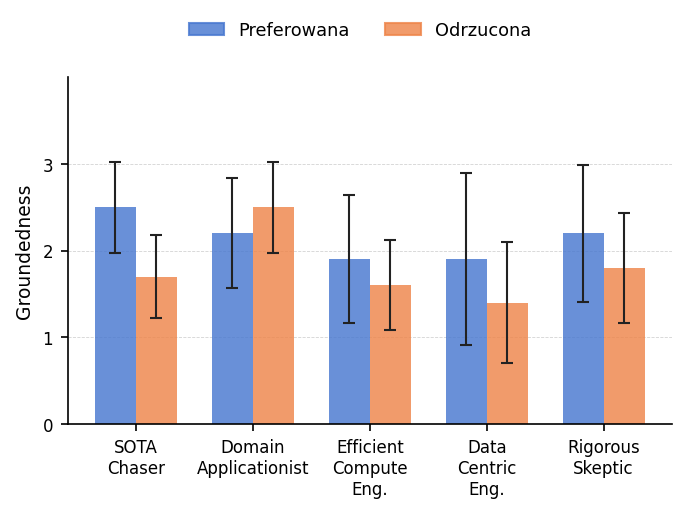

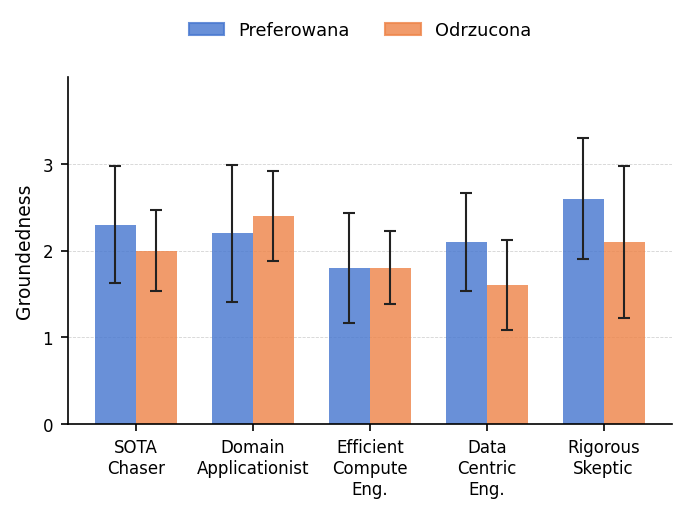

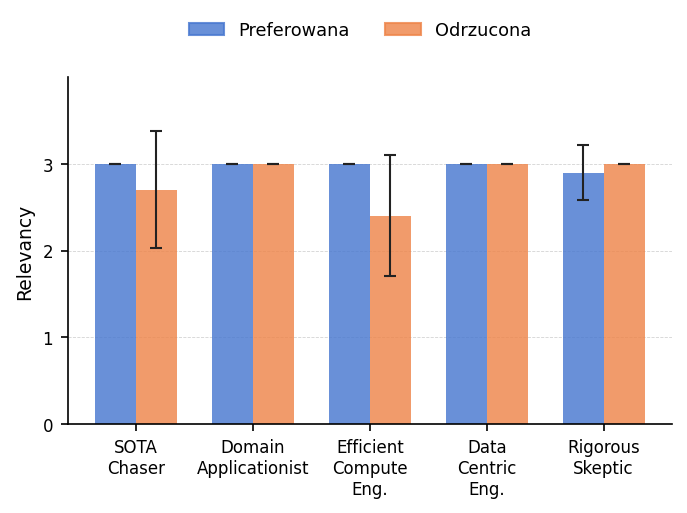

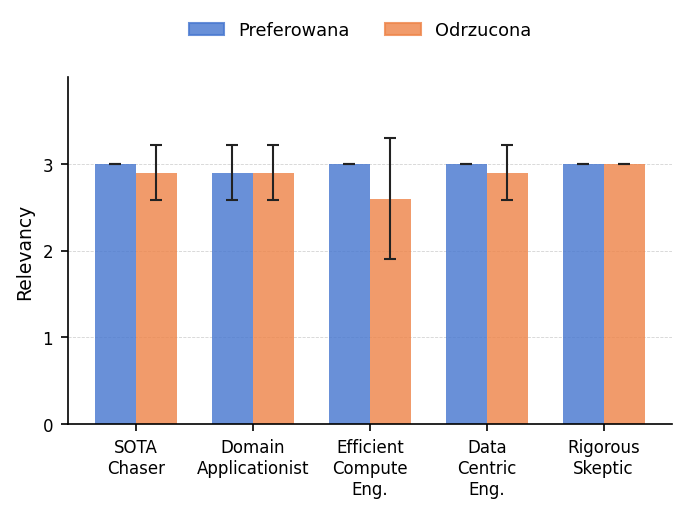

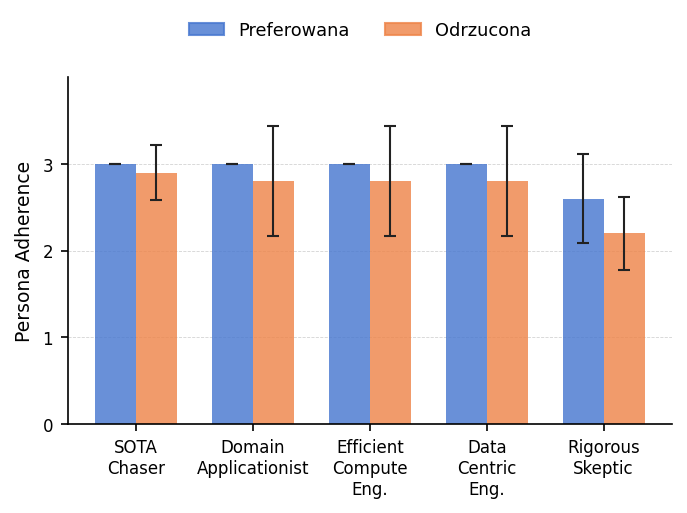

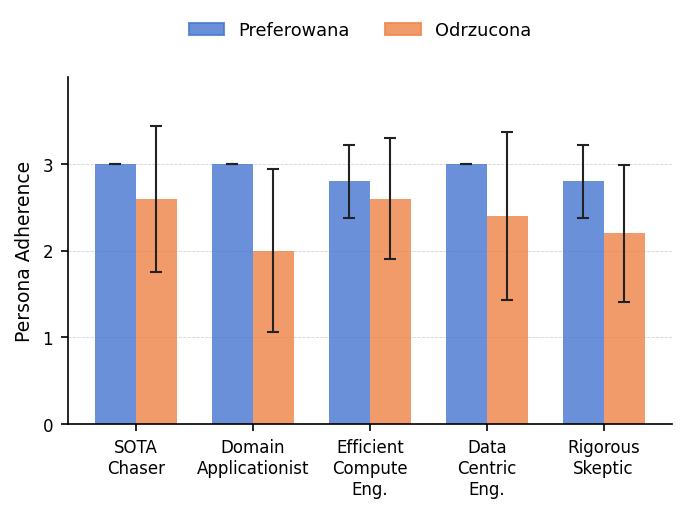

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ─────────────────────────────────────────────────────────────────────
df3 = pd.read_csv("eval-dpo-gemma.csv")
df2 = pd.read_csv("../../final_2/data_eval/dpo-gemma.csv")

metrics = ["groundedness_score", "relevancy_score", "persona_adherence_score"]
labels  = ["Groundedness", "Relevancy", "Persona Adherence"]

PERSONAS = ["sota_chaser", "domain_expert", "efficient_compute", "data_engineer",
            "rigorous_skeptic"]

PERSONA_LABELS = ["SOTA\nChaser", "Domain\nApplicationist", "Efficient\nCompute\nEng.", "Data\nCentric\nEng.",
                  "Rigorous\nSkeptic"]
HYP_TYPES    = ["chosen", "rejected"]
HYP_DISPLAY  = {"chosen": "Preferowana", "rejected": "Odrzucona"}

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
})

COLORS    = {"chosen": "#4878D0", "rejected": "#EE854A"}
BAR_WIDTH = 0.35
CAPSIZE   = 3
ALPHA     = 0.82
ERROR_KW  = dict(elinewidth=1.0, ecolor="#222", capthick=1.0, zorder=5)
YMAX      = 4.0   # headroom above max mean+std ≈ 3.44


def agg(df, metric):
    return df.groupby(["persona", "hypothesis_type"])[metric].agg(["mean", "std"])


def make_figure(df, metric, ylabel):
    """Single grouped-bar figure for one dataset and one metric."""
    stats = agg(df, metric)
    x = np.arange(len(PERSONAS))
    offsets = {"chosen": -BAR_WIDTH / 2, "rejected": BAR_WIDTH / 2}

    fig, ax = plt.subplots(figsize=(5.2, 3.0))

    for htype in HYP_TYPES:
        means, stds = [], []
        for p in PERSONAS:
            try:
                row = stats.loc[(p, htype)]
                means.append(row["mean"])
                stds.append(row["std"] if not np.isnan(row["std"]) else 0)
            except KeyError:
                means.append(0); stds.append(0)

        ax.bar(x + offsets[htype], means, width=BAR_WIDTH,
               color=COLORS[htype], alpha=ALPHA, zorder=2,
               yerr=stds, capsize=CAPSIZE, error_kw=ERROR_KW)

    ax.set_xticks(x)
    ax.set_xticklabels(PERSONA_LABELS, linespacing=1.2)
    ax.set_ylim(0, YMAX)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.55, zorder=0)

    return fig


# ── Legend patches (shared) ───────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=COLORS[h], alpha=ALPHA, label=HYP_DISPLAY[h])
    for h in HYP_TYPES
]

# ── Generate 2 separate figures per metric (6 total) ─────────────────────────
for metric, label in zip(metrics, labels):
    for df, suffix in [(df3, "final_3"), (df2, "final_2")]:
        fig = make_figure(df, metric, ylabel=label)
        fig.legend(handles=legend_patches, loc="upper center",
                   ncol=2, frameon=False, fontsize=8.5,
                   bbox_to_anchor=(0.5, 1.04))
        fig.savefig(f"plot_{metric}_{suffix}.png", bbox_inches="tight")
        plt.show()


In [3]:
# ── Tabela LaTeX: porównanie metryk między final_2 a final_3 ─────────────────
datasets   = {"final\\_3": df3, "final\\_2": df2}
hyp_types  = {"chosen": "Preferowana", "rejected": "Odrzucona"}
metric_tex = {
    "groundedness_score":      "Groundedness",
    "relevancy_score":         "Relevancy",
    "persona_adherence_score": "Persona Adherence",
}

# Zbierz statystyki: dataset × hypothesis_type × metric → (mean, std)
def fmt_cell(df, htype, metric):
    vals = df.loc[df["hypothesis_type"] == htype, metric].dropna()
    return rf"{vals.mean():.2f} $\pm$ {vals.std():.2f}"

n_metrics = len(metric_tex)
col_spec = "ll" + "r" * n_metrics

header_metrics = " & ".join(metric_tex.values())
cmidrule = f"\\cmidrule(lr){{3-{2 + n_metrics}}}"

lines = [
    "\\begin{table}[h]",
    "  \\centering",
    "  \\small",
    f"  \\begin{{tabular}}{{{col_spec}}}",
    "    \\toprule",
    f"    Metoda & Hipoteza & {header_metrics} \\\\",
    "    \\midrule",
]

for i, (ds_label, df_ds) in enumerate(datasets.items()):
    for j, (htype, htype_label) in enumerate(hyp_types.items()):
        cells = [
            fmt_cell(df_ds, htype, m) for m in metric_tex
        ]
        row = f"    {ds_label} & {htype_label} & " + " & ".join(cells) + " \\\\"
        lines.append(row)
    if i < len(datasets) - 1:
        lines.append("    \\midrule")

lines += [
    "    \\bottomrule",
    "  \\end{tabular}",
    "  \\caption{Porównanie metryk oceny hipotez (średnia $\\pm$ odch. std.) "
    "dla zbioru final\\_3 i final\\_2.}",
    "  \\label{tab:metrics_comparison}",
    "\\end{table}",
]

print("\n".join(lines))

\begin{table}[h]
  \centering
  \small
  \begin{tabular}{llrrr}
    \toprule
    Metoda & Hipoteza & Groundedness & Relevancy & Persona Adherence \\
    \midrule
    final\_3 & Preferowana & 2.14 $\pm$ 0.76 & 2.98 $\pm$ 0.14 & 2.92 $\pm$ 0.27 \\
    final\_3 & Odrzucona & 1.80 $\pm$ 0.67 & 2.82 $\pm$ 0.48 & 2.70 $\pm$ 0.58 \\
    \midrule
    final\_2 & Preferowana & 2.20 $\pm$ 0.70 & 2.98 $\pm$ 0.14 & 2.92 $\pm$ 0.27 \\
    final\_2 & Odrzucona & 1.98 $\pm$ 0.62 & 2.86 $\pm$ 0.40 & 2.36 $\pm$ 0.85 \\
    \bottomrule
  \end{tabular}
  \caption{Porównanie metryk oceny hipotez (średnia $\pm$ odch. std.) dla zbioru final\_3 i final\_2.}
  \label{tab:metrics_comparison}
\end{table}


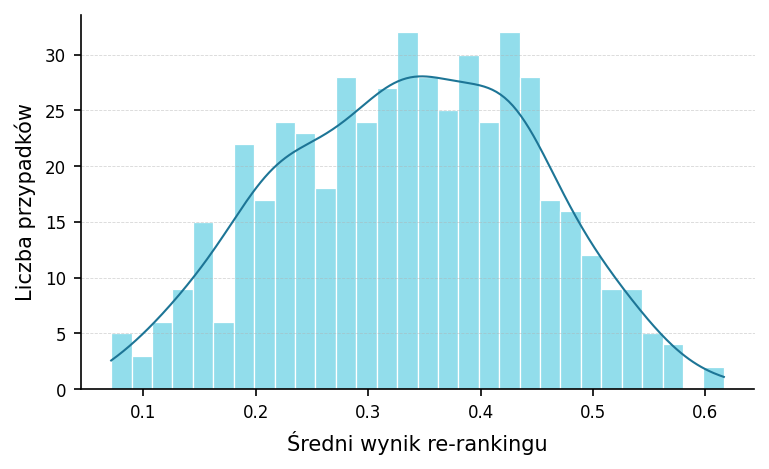

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ── Dane ─────────────────────────────────────────────────────────────────────
df_rerank = pd.read_csv("../../final_2/dpo_new_hypotheses_qwen3.5.csv")

# ── Styl ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
})

data = df_rerank["chosen_average_rerank_score"].dropna()

fig, ax = plt.subplots(figsize=(5.2, 3.2))

sns.histplot(
    data,
    bins=30,
    color="#7FD8E8",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.6,
    kde=False,
    ax=ax,
    stat="count",
)

# KDE skalowane do liczby przypadków
bin_width = (data.max() - data.min()) / 30
kde = gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 300)
ax.plot(x_range, kde(x_range) * len(data) * bin_width,
        color="#1d7596", linewidth=1)

ax.set_xlabel("Średni wynik re-rankingu")
ax.set_ylabel("Liczba przypadków")
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5, zorder=0)

plt.tight_layout()
plt.savefig("plot_rerank_distribution.png", bbox_inches="tight")
plt.show()


In [16]:
stats = {
    "Średnia":              data.mean(),
    "Odch. standardowe":    data.std(),
    "Mediana":              data.median(),
}

rows = "\n".join(
    rf"    {name} & {value:.4f} \\" for name, value in stats.items()
)

latex = rf"""\begin{{table}}[h]
  \centering
  \small
  \begin{{tabular}}{{lr}}
    \toprule
    Statystyka & Wartość \\
    \midrule
{rows}
    \bottomrule
  \end{{tabular}}
  \caption{{Statystyki średniego wyniku re-rankingu.}}
  \label{{tab:rerank_stats}}
\end{{table}}"""

print(latex)


\begin{table}[h]
  \centering
  \small
  \begin{tabular}{lr}
    \toprule
    Statystyka & Wartość \\
    \midrule
    Średnia & 0.3349 \\
    Odch. standardowe & 0.1125 \\
    Mediana & 0.3382 \\
    \bottomrule
  \end{tabular}
  \caption{Statystyki średniego wyniku re-rankingu.}
  \label{tab:rerank_stats}
\end{table}
